# Training: one picture of a person -> a posed MHR body

The network takes a 256x256 crop of a person and predicts **49 numbers**:

| what | how many | why |
|---|---|---|
| joint angles | 31 | the pose: spine, neck, head, shoulders, elbows, hips, knees |
| build scales | 9 | how long this person's bones are |
| root rotation | 6 | which way the body faces, as two vectors rather than three angles |
| position | 3 | where the body sits in the crop, and how big the crop is in metres |

The labels come from `mhr_posing/analytic_ik.py`, which turns ASPset-510's
ground-truth 3D keypoints into MHR parameters. Nothing here is hand-annotated.

Run the cells in order. **The first run builds a cache of person crops** -- about
five minutes and 170 MB, because seeking in a 4K video takes 0.31 s per frame and
reading it in order takes 0.006 s. After that, training never touches the videos.

In [1]:
import collections
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_pose_net":
    HERE = HERE / "mhr_pose_net"          # started from the project root
sys.path.insert(0, str(HERE))

import data
import model
import analytic_ik as ik

rig = ik.Rig()                # the MHR rig -- we only need its skeleton, so the coarse mesh
body = model.Body(rig)        # the same rig, as a differentiable layer inside the loss

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

print("device:", DEVICE)
print(f"{len(data.ANGLE_PARAMS)} joint angles + {len(data.SCALE_PARAMS)} build scales"
      f" + 6 root rotation + 3 position = {model.N_OUTPUTS} numbers")
print("joint angles:", ", ".join(data.ANGLE_PARAMS[:6]), "...")

device: mps
31 joint angles + 9 build scales + 6 root rotation + 3 position = 49 numbers
joint angles: spine0_rx_flexible, spine0_ry_flexible, spine0_rz_flexible, l_clavicle_rx, l_clavicle_ry, l_clavicle_rz ...


## 1. Build the cache

Walks each video once, in order, solves every second frame with the analytic
solver, and saves a small JPEG crop plus the labels. Skips clips it has already
done, so re-running is free.

In [2]:
data.build_cache(rig, stride=2)

cache ready: 60 clips, 179 MB in /Users/rzt/Documents/mhr_env/mhr_pose_net/cache


## 2. Split the clips

**Whole clips are held back, not individual frames.** The videos run at 50 fps,
so two neighbouring frames are almost the same picture -- splitting by frame
would let the network study the answers to its own test.

There are only two people in ASPset-510, and both appear on both sides of this
split. So the validation score measures *"can it handle an action and a camera
angle it has not seen"*, not *"can it handle a new person"*. That second question
needs a dataset with more subjects.

In [3]:
BATCH = 24
WORKERS = 0          # the cache makes loading cheap: 2 ms a frame, 20% of a training step.
                     # On Linux, 4 shaves that off; on macOS it is more trouble than it saves.

train_clips, val_clips = data.split_clips(every=6)
train_data = data.PoseData(train_clips, augment=True)
val_data = data.PoseData(val_clips, augment=False)

train_loader = DataLoader(train_data, batch_size=BATCH, shuffle=True,
                          num_workers=WORKERS, drop_last=True)
val_loader = DataLoader(val_data, batch_size=BATCH, num_workers=WORKERS)

print(f"training   {len(train_clips):2d} clips, {len(train_data):5d} frames")
print(f"held back  {len(val_clips):2d} clips, {len(val_data):5d} frames")
print("held back:", ", ".join(val_clips))

training   50 clips,  5559 frames
held back  10 clips,  1310 frames
held back: 1e28-0001-left, 1e28-0021-mid, 1e28-0038-left, 1e28-0065-left, 1e28-0080-right, 8a59-0006-mid, 8a59-0019-left, 8a59-0040-left, 8a59-0071-right, 8a59-0093-mid


## 3. The network

`resnet18` is the default because ASPset-510 has two subjects: a bigger backbone
memorises them instead of learning. `resnet34` and `resnet50` are one word away
if you move to a larger dataset.

The head starts out predicting the *average* pose of the training set rather than
a random one, which saves the first few epochs.

In [ ]:
BACKBONE = "resnet18"        # "resnet18" | "resnet34" | "resnet50"
EPOCHS = 25
LEARNING_RATE = 2e-4

torch.manual_seed(0)
net = model.PoseNet(BACKBONE, average=model.average_outputs(train_data)).to(DEVICE)
optimiser = torch.optim.AdamW(net.parameters(), LEARNING_RATE, weight_decay=1e-4)
schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, EPOCHS)

print(f"{BACKBONE}: {sum(p.numel() for p in net.parameters()) / 1e6:.1f} M parameters")

resnet18: 11.5 M parameters


## 4. Train

Two lines are worth understanding.

`run()` sends the picture to the GPU and brings the 49 numbers straight back.
The backbone runs on the GPU; the MHR rig inside the loss only runs on the CPU,
because `pymomentum` has no Apple GPU backend. That is fine -- posing a batch of
24 costs about 6 ms -- and gradients cross between the two devices by themselves.

`model.compute_loss` is where the rig earns its place: as well as comparing the
49 numbers, it *poses the body* and *projects it through the real camera*, so the
loss knows that a shoulder angle moves the hand ten times further than a wrist
angle does.

In [5]:
def run(batch):
    """The network's answer for one batch, brought back to the CPU."""
    out = net(batch["image"].to(DEVICE), batch["box"].to(DEVICE),
              batch["intrinsics"].to(DEVICE))
    return {name: value.cpu() for name, value in out.items()}


def validate():
    """Average loss and readable scores over the held-back clips."""
    net.eval()
    totals, seen = collections.Counter(), 0
    for batch in val_loader:
        with torch.no_grad():
            prediction = run(batch)
        loss, _ = model.compute_loss(prediction, batch, body)
        count = len(batch["image"])
        totals.update({k: v * count for k, v in model.metrics(prediction, batch, body).items()})
        totals["loss"] += float(loss) * count
        seen += count
    return {name: value / seen for name, value in totals.items()}


history, best = [], float("inf")
for epoch in range(1, EPOCHS + 1):
    net.train()
    started, running = time.time(), 0.0
    for batch in train_loader:
        loss, parts = model.compute_loss(run(batch), batch, body)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        running += float(loss)
    schedule.step()

    scores = validate()
    scores["train_loss"] = running / len(train_loader)
    history.append(scores)

    if scores["loss"] < best:
        best = scores["loss"]
        torch.save({"backbone": BACKBONE, "weights": net.state_dict()}, HERE / "checkpoint.pt")
        mark = "  <- saved"
    else:
        mark = ""

    print(f"epoch {epoch:3d}  train {scores['train_loss']:.3f}  val {scores['loss']:.3f}"
          f"   {scores['mpjpe_mm']:5.0f} mm  {scores['pixel_error']:5.1f} px"
          f"  {scores['rotation_deg']:4.1f} deg   {time.time() - started:3.0f} s{mark}")

epoch   1  train 0.725  val 0.518     127 mm   21.5 px  19.6 deg    66 s  <- saved


epoch   2  train 0.509  val 0.469     122 mm   18.8 px  18.0 deg    68 s  <- saved


epoch   3  train 0.455  val 0.444     113 mm   17.3 px  14.8 deg    66 s  <- saved


epoch   4  train 0.427  val 0.408     102 mm   16.1 px  12.7 deg    65 s  <- saved


epoch   5  train 0.404  val 0.423     106 mm   17.7 px  13.7 deg    66 s


...

epoch  21  train 0.280  val 0.367      92 mm   13.0 px  12.4 deg    66 s


epoch  22  train 0.277  val 0.363      92 mm   13.0 px  11.9 deg    65 s


epoch  23  train 0.275  val 0.361      91 mm   12.9 px  12.0 deg    66 s  <- saved


epoch  24  train 0.274  val 0.362      92 mm   12.8 px  12.1 deg    66 s


epoch  25  train 0.274  val 0.361      91 mm   12.7 px  12.1 deg    65 s


## 5. How it went

The dashed line is the floor: the score you get by feeding the *ground-truth
labels* straight into the same measurement. It is not zero, because the analytic
solver aims MHR's joint centres at ASPset's skin markers, and those are a few
centimetres apart by definition. No network trained on these labels can beat it.

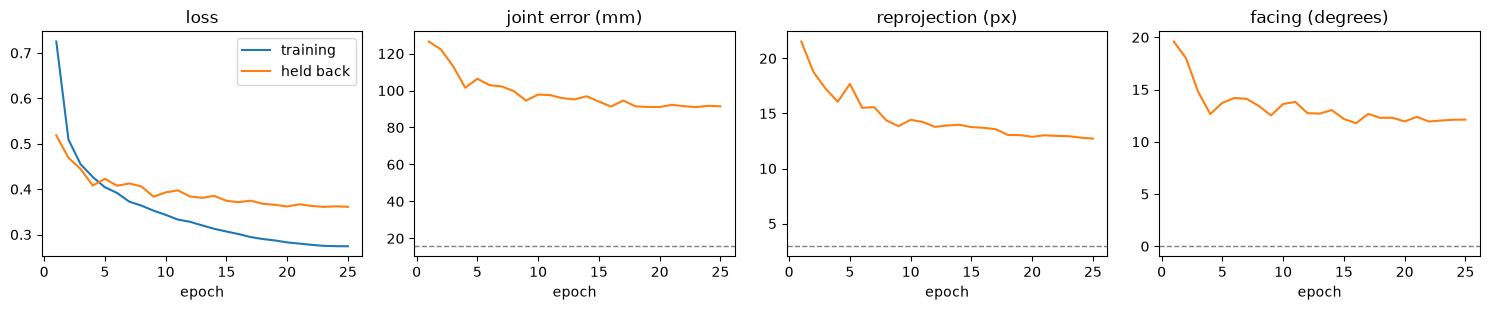

best held-back scores
  mpjpe_mm           91.02      (floor 15.71)
  pixel_error        12.94      (floor 2.94)
  root_error_cm      23.92      (floor 0.00)
  rotation_deg       12.04      (floor 0.00)

saved to /Users/rzt/Documents/mhr_env/mhr_pose_net/checkpoint.pt -- open infer.ipynb to look at it


In [6]:
gt_totals, seen = collections.Counter(), 0
for batch in val_loader:
    truth = dict(angles=batch["angles"], scales=batch["scales"], rotation=batch["root_rot"],
                 camera=model.camera_target(batch["joints"][:, data.PELVIS],
                                            batch["box"], batch["intrinsics"]))
    count = len(batch["image"])
    gt_totals.update({k: v * count for k, v in model.metrics(truth, batch, body).items()})
    seen += count
floor = {name: value / seen for name, value in gt_totals.items()}

epochs = np.arange(1, len(history) + 1)
figure, axes = plt.subplots(1, 4, figsize=(15, 3.2))
axes[0].plot(epochs, [h["train_loss"] for h in history], label="training")
axes[0].plot(epochs, [h["loss"] for h in history], label="held back")
axes[0].set(title="loss", xlabel="epoch")
axes[0].legend()
for ax, key, title in zip(axes[1:], ("mpjpe_mm", "pixel_error", "rotation_deg"),
                          ("joint error (mm)", "reprojection (px)", "facing (degrees)")):
    ax.plot(epochs, [h[key] for h in history], color="tab:orange")
    ax.axhline(floor[key], ls="--", c="grey", lw=1)
    ax.set(title=title, xlabel="epoch")
plt.tight_layout()
plt.show()

print("best held-back scores")
best_epoch = min(history, key=lambda h: h["loss"])
for name in ("mpjpe_mm", "pixel_error", "root_error_cm", "rotation_deg"):
    print(f"  {name:15s} {best_epoch[name]:8.2f}      (floor {floor[name]:.2f})")
print(f"\nsaved to {HERE / 'checkpoint.pt'} -- open infer.ipynb to look at it")